<a href="https://colab.research.google.com/github/yuriehan/ee559project/blob/main/speech_emotion_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install kagglehub librosa

import kagglehub
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from collections import Counter

#Sklearn for SVM
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score

#Keras/TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Dataset Loading

In [ ]:
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print(f"Dataset downloaded to: {path}")

DATA_PATH = os.path.join(path, "audio_speech_actors_01-24")

print(f"Using data path: {DATA_PATH}")

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Dataset downloaded to: /kaggle/input/ravdess-emotional-speech-audio
Using data path: /kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24


Feature Extraction - MFCCs for SVM

In [ ]:
def extract_mfcc_features(file_path):
    try:
        y_audio, sr = librosa.load(file_path, duration=3, offset=0.5)
        mfcc   = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=20)
        delta  = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
        combined = np.concatenate([mfcc, delta, delta2], axis=0)
        return np.mean(combined.T, axis=0)   #shape: (60,)
    except Exception as e:
        print(f"MFCC error {file_path}: {e}")
        return None

Feature Extraction - Mel-Spectrograms for CNN

In [ ]:
MEL_SHAPE = (128, 128)   #(n_mels, fixed time frames)

def extract_mel_spectrogram(file_path):
    try:
        y_audio, sr = librosa.load(file_path, duration=3, offset=0.5)
        mel = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=MEL_SHAPE[0])
        mel_db = librosa.power_to_db(mel, ref=np.max)   #convert to dB scale

        #Pad or truncate time axis to fixed width
        if mel_db.shape[1] < MEL_SHAPE[1]:
            pad_width = MEL_SHAPE[1] - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_db = mel_db[:, :MEL_SHAPE[1]]

        return mel_db   #shape: (128, 128)
    except Exception as e:
        print(f"Mel error {file_path}: {e}")
        return None

Build Dataset

In [ ]:
X_mfcc, X_mel, y_labels = [], [], []

for actor in sorted(os.listdir(DATA_PATH)):
    actor_path = os.path.join(DATA_PATH, actor)
    if not os.path.isdir(actor_path):
        continue
    for file in sorted(os.listdir(actor_path)):
        if not file.endswith(".wav"):
            continue
        file_path = os.path.join(actor_path, file)
        emotion_code = file.split("-")[2]
        emotion = emotion_map.get(emotion_code)
        if emotion is None:
            continue

        mfcc_feat = extract_mfcc_features(file_path)
        mel_feat  = extract_mel_spectrogram(file_path)

        if mfcc_feat is not None and mel_feat is not None:
            X_mfcc.append(mfcc_feat)
            X_mel.append(mel_feat)
            y_labels.append(emotion)

X_mfcc = np.array(X_mfcc) #(N, 60)
X_mel = np.array(X_mel)[..., np.newaxis] #(N, 128, 128, 1) — channel dim for CNN
y = np.array(y_labels)

print(f"\nMFCC feature matrix: {X_mfcc.shape}")
print(f"Mel spectrogram tensor: {X_mel.shape}")
print(f"Labels: {y.shape}")


MFCC feature matrix: (1440, 60)
Mel spectrogram tensor: (1440, 128, 128, 1)
Labels: (1440,)


Encode Labels

In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
n_classes = len(encoder.classes_)
print(f"\nClasses ({n_classes}):", encoder.classes_)


Classes (8): ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


Class Distribution Plot

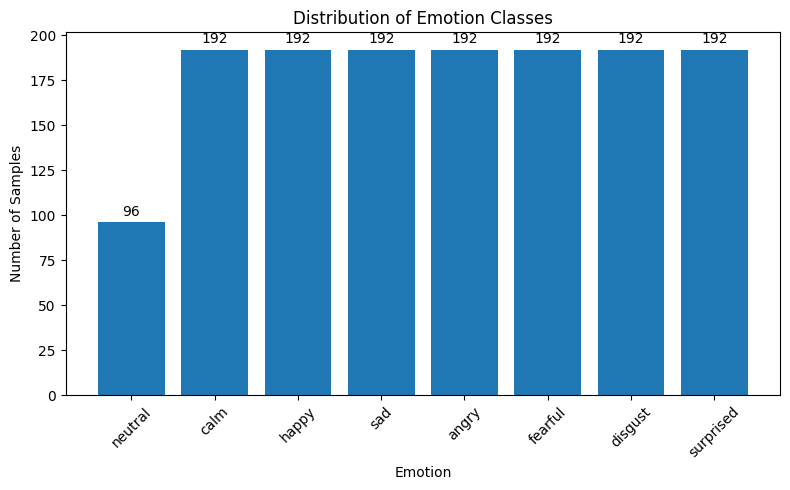

Class distribution: Counter({np.str_('calm'): 192, np.str_('happy'): 192, np.str_('sad'): 192, np.str_('angry'): 192, np.str_('fearful'): 192, np.str_('disgust'): 192, np.str_('surprised'): 192, np.str_('neutral'): 96})


In [ ]:
counts = Counter(y)
plt.figure(figsize=(8, 5))
bars = plt.bar(counts.keys(), counts.values())
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 2, str(int(h)),
             ha='center', va='bottom')
plt.xticks(rotation=45)
plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Class distribution:", counts)

Train/Validation/Test Split (70/15/15, stratified)

In [ ]:
#Indices — same split applied to both MFCC and Mel features
idx = np.arange(len(y_encoded))

idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=42,
                                        stratify=y_encoded)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42,
                                        stratify=y_encoded[idx_temp])

#MFCC splits for SVM/LR
X_mfcc_train = X_mfcc[idx_train]
X_mfcc_val   = X_mfcc[idx_val]
X_mfcc_test  = X_mfcc[idx_test]

#Mel splits for CNN
X_mel_train  = X_mel[idx_train]
X_mel_val    = X_mel[idx_val]
X_mel_test   = X_mel[idx_test]

#labels
y_train = y_encoded[idx_train]
y_val   = y_encoded[idx_val]
y_test  = y_encoded[idx_test]

print(f"\nTrain / Val / Test: {len(idx_train)} / {len(idx_val)} / {len(idx_test)}")

#scale MFCC features, fit only on train
scaler = StandardScaler()
X_mfcc_train_sc = scaler.fit_transform(X_mfcc_train)
X_mfcc_val_sc = scaler.transform(X_mfcc_val)
X_mfcc_test_sc = scaler.transform(X_mfcc_test)

#normalize Mel spectrograms to [0, 1], fit only on train
mel_min = X_mel_train.min()
mel_max = X_mel_train.max()
X_mel_train_n = (X_mel_train - mel_min) / (mel_max - mel_min)
X_mel_val_n = (X_mel_val   - mel_min) / (mel_max - mel_min)
X_mel_test_n = (X_mel_test  - mel_min) / (mel_max - mel_min)


Train / Val / Test: 1008 / 216 / 216


Improved SVM - GridSearchCV with gamma


SVM GridSearchCV
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best SVM params:   {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1 (macro): 0.4478
SVM Val Accuracy: 0.4259
SVM Test Accuracy: 0.4583
SVM Test F1 (macro): 0.4382


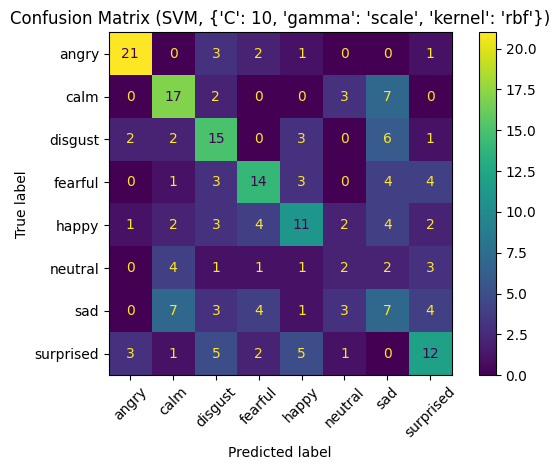


Classification Report (SVM):
              precision    recall  f1-score   support

       angry       0.78      0.75      0.76        28
        calm       0.50      0.59      0.54        29
     disgust       0.43      0.52      0.47        29
     fearful       0.52      0.48      0.50        29
       happy       0.44      0.38      0.41        29
     neutral       0.18      0.14      0.16        14
         sad       0.23      0.24      0.24        29
   surprised       0.44      0.41      0.43        29

    accuracy                           0.46       216
   macro avg       0.44      0.44      0.44       216
weighted avg       0.46      0.46      0.46       216



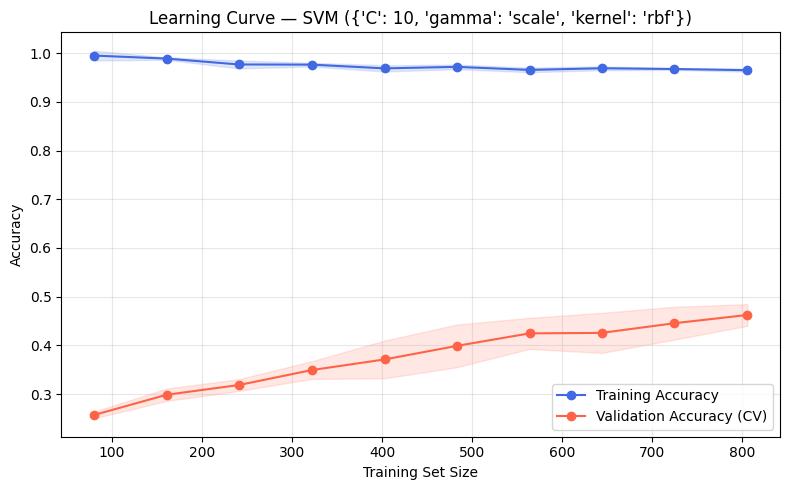

In [ ]:
print("\nSVM GridSearchCV")

#hyperparameters to tune
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro', #better than accuracy for imbalanced neutral class
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_mfcc_train_sc, y_train)

print(f"\nBest SVM params:   {grid_search.best_params_}")
print(f"Best CV F1 (macro): {grid_search.best_score_:.4f}")

best_svm = grid_search.best_estimator_

# Evaluate on val and test
svm_val_acc  = best_svm.score(X_mfcc_val_sc,  y_val)
svm_test_acc = best_svm.score(X_mfcc_test_sc, y_test)
y_svm_pred   = best_svm.predict(X_mfcc_test_sc)
svm_f1       = f1_score(y_test, y_svm_pred, average='macro')

print(f"SVM Val Accuracy: {svm_val_acc:.4f}")
print(f"SVM Test Accuracy: {svm_test_acc:.4f}")
print(f"SVM Test F1 (macro): {svm_f1:.4f}")

# Confusion matrix — SVM
cm_svm = confusion_matrix(y_test, y_svm_pred)
disp = ConfusionMatrixDisplay(cm_svm, display_labels=encoder.classes_)
disp.plot(xticks_rotation=45)
plt.title(f"Confusion Matrix (SVM, {grid_search.best_params_})")
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150)
plt.show()

print("\nClassification Report (SVM):")
print(classification_report(y_test, y_svm_pred, target_names=encoder.classes_))

# Learning curve — SVM
bp = grid_search.best_params_
train_sizes, train_scores, val_scores = learning_curve(
    SVC(C=bp['C'], kernel=bp['kernel'], gamma=bp.get('gamma', 'scale'),
        class_weight='balanced', random_state=42),
    X_mfcc_train_sc, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='blue', label='Training Accuracy')
plt.plot(train_sizes, np.mean(val_scores,   axis=1), 'o-', color='red',    label='Validation Accuracy (CV)')
plt.fill_between(train_sizes,
                 np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                 np.mean(train_scores, axis=1) + np.std(train_scores, axis=1),
                 alpha=0.15, color='blue')
plt.fill_between(train_sizes,
                 np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                 np.mean(val_scores, axis=1) + np.std(val_scores, axis=1),
                 alpha=0.15, color='red')
plt.title(f"Learning Curve — SVM ({bp})")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve_svm.png", dpi=150)
plt.show()

CNN - Transfer Learning with MobileNetV2


Balanced train set: 1080 samples
Class counts after oversampling: Counter({np.int64(7): 135, np.int64(4): 135, np.int64(6): 135, np.int64(2): 135, np.int64(0): 135, np.int64(1): 135, np.int64(3): 135, np.int64(5): 135})
RGB input shape: (1080, 128, 128, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Phase 1: Training head (base frozen)
Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 534ms/step - accuracy: 0.2833 - loss: 1.9316 - val_accuracy: 0.3750 - val_loss: 1.7250
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 473ms/step - accuracy: 0.4500 - loss: 1.4926 - val_accuracy: 0.3981 - val_loss: 1.6263
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 469ms/step - accuracy: 0.5389 - loss: 1.3414 - val_accuracy: 0.4167 - val_loss: 1.5262
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 474ms/step - accuracy: 0.5833 - loss: 1.1759 - val_accuracy: 0.4630 - val_loss: 1.4805
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 483ms/step - accuracy: 0.6343 - loss: 1.0422 - val_accuracy: 0.4167 - val_loss: 1.4431
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 483ms/step - accuracy: 0.6667 - loss: 0.9596 - val_accuracy: 0.4537 - val_loss: 1.4252
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 563ms/step - accuracy: 0.7176 - loss: 0.8612 - val_accuracy: 0.4583 - val_loss: 1.4082
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 469ms/step - accu

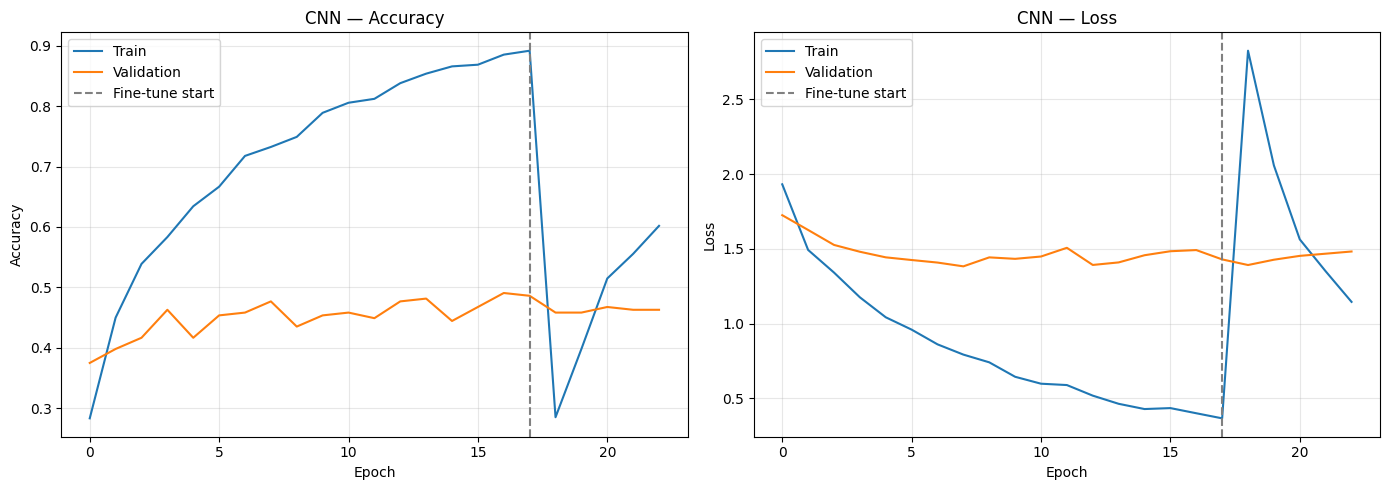

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 582ms/step

CNN Test Accuracy: 0.5509
CNN Test F1 (macro): 0.5253


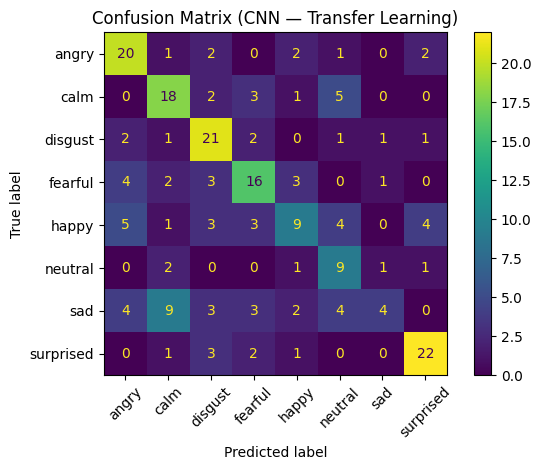


Classification Report (CNN):
              precision    recall  f1-score   support

       angry       0.57      0.71      0.63        28
        calm       0.51      0.62      0.56        29
     disgust       0.57      0.72      0.64        29
     fearful       0.55      0.55      0.55        29
       happy       0.47      0.31      0.38        29
     neutral       0.38      0.64      0.47        14
         sad       0.57      0.14      0.22        29
   surprised       0.73      0.76      0.75        29

    accuracy                           0.55       216
   macro avg       0.54      0.56      0.53       216
weighted avg       0.56      0.55      0.53       216



In [ ]:
unique_classes, counts_per_class = np.unique(y_train, return_counts=True)
max_count = counts_per_class.max()

X_mel_train_bal_list, y_train_bal_list = [], []
for cls in unique_classes:
    idx_cls = np.where(y_train == cls)[0]
    idx_resampled = resample(idx_cls, replace=True,
                             n_samples=max_count, random_state=42)
    X_mel_train_bal_list.append(X_mel_train_n[idx_resampled])
    y_train_bal_list.append(y_train[idx_resampled])

X_mel_train_bal = np.concatenate(X_mel_train_bal_list, axis=0)
y_train_bal = np.concatenate(y_train_bal_list,     axis=0)

#shuffle
rng = np.random.default_rng(42)
shuffle_idx = rng.permutation(len(y_train_bal))
X_mel_train_bal = X_mel_train_bal[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

print(f"\nBalanced train set: {X_mel_train_bal.shape[0]} samples")
print("Class counts after oversampling:", Counter(y_train_bal))

#convert (128, 128, 1) to (128, 128, 3) for MobileNetV2
X_mel_train_rgb = np.repeat(X_mel_train_bal, 3, axis=-1)
X_mel_val_rgb = np.repeat(X_mel_val_n, 3, axis=-1)
X_mel_test_rgb = np.repeat(X_mel_test_n, 3, axis=-1)

print(f"RGB input shape: {X_mel_train_rgb.shape}")

#build model
def build_transfer_cnn(input_shape, n_classes):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False   #freeze for Phase 1

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs), base_model

input_shape_rgb = (128, 128, 3)
cnn_model, base_model = build_transfer_cnn(input_shape_rgb, n_classes)
cnn_model.summary()

#Phase 1: train head only
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_p1 = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)

print("\nPhase 1: Training head (base frozen)")
history_p1 = cnn_model.fit(
    X_mel_train_rgb, y_train_bal,
    validation_data=(X_mel_val_rgb, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_p1],
    verbose=1
)

#record best val_loss from Phase 1 to use as baseline in Phase 2
best_p1_val_loss = min(history_p1.history['val_loss'])
print(f"\nPhase 1 best val_loss: {best_p1_val_loss:.4f}")

#Phase 2: Fine-tune top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Fine-tuning top 30 layers of MobileNetV2")

#much smaller lr to avoid destroying pretrained weights
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_p2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    baseline=best_p1_val_loss, #only accept improvements over Phase 1
    verbose=1
)

print("\nPhase 2: Fine-tuning")
history_p2 = cnn_model.fit(
    X_mel_train_rgb, y_train_bal,
    validation_data=(X_mel_val_rgb, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_p2],
    verbose=1
)

#Training curves (both phases combined)
p1_epochs = len(history_p1.history['loss'])

acc = history_p1.history['accuracy'] + history_p2.history['accuracy']
val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss = history_p1.history['loss'] + history_p2.history['loss']
val_loss = history_p1.history['val_loss'] + history_p2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, train_vals, val_vals, title, ylabel in [
    (axes[0], acc, val_acc, "CNN — Accuracy", "Accuracy"),
    (axes[1], loss, val_loss, "CNN — Loss", "Loss"),
]:
    ax.plot(train_vals, label='Train')
    ax.plot(val_vals, label='Validation')
    ax.axvline(x=p1_epochs - 1, color='gray', linestyle='--',
               label='Fine-tune start')
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_cnn.png", dpi=150)
plt.show()

#evaluate CNN on test set
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_mel_test_rgb, y_test, verbose=0)
y_cnn_pred = np.argmax(cnn_model.predict(X_mel_test_rgb), axis=1)
cnn_f1     = f1_score(y_test, y_cnn_pred, average='macro')

print(f"\nCNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"CNN Test F1 (macro): {cnn_f1:.4f}")

#Confusion matrix — CNN
cm_cnn = confusion_matrix(y_test, y_cnn_pred)
disp = ConfusionMatrixDisplay(cm_cnn, display_labels=encoder.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix (CNN — Transfer Learning)")
plt.tight_layout()
plt.savefig("confusion_matrix_cnn.png", dpi=150)
plt.show()

print("\nClassification Report (CNN):")
print(classification_report(y_test, y_cnn_pred, target_names=encoder.classes_))

Final Comparison

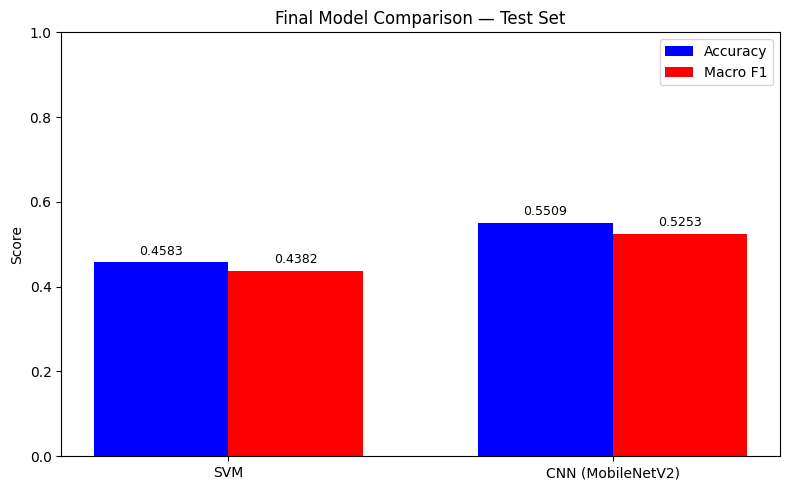

In [ ]:
models = ['SVM', 'CNN (MobileNetV2)']
test_accs = [svm_test_acc, cnn_test_acc]
test_f1s = [svm_f1, cnn_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, test_accs, width, label='Accuracy', color='blue')
bars2 = ax.bar(x + width/2, test_f1s, width, label='Macro F1', color='red')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
            f"{h:.4f}", ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Score")
ax.set_title("Final Model Comparison — Test Set")
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

Final Summary

In [ ]:
print("Summary")
print(f"Dataset: {len(y)} samples, {n_classes} classes")
print(f"SVM features: {X_mfcc.shape[1]} (MFCC + delta + delta-delta)")
print(f"CNN input shape: {input_shape_rgb} (Mel-spectrogram, 3-channel)")
print(f"Train / Val / Test: {len(idx_train)} / {len(idx_val)} / {len(idx_test)}")
print(f"\nBest SVM params: {grid_search.best_params_}")
print(f"SVM  Test Acc: {svm_test_acc:.4f} F1: {svm_f1:.4f}")
print(f"CNN  Test Acc: {cnn_test_acc:.4f} F1: {cnn_f1:.4f}")

Summary
Dataset: 1440 samples, 8 classes
SVM features: 60 (MFCC + delta + delta-delta)
CNN input shape: (128, 128, 3) (Mel-spectrogram, 3-channel)
Train / Val / Test: 1008 / 216 / 216

Best SVM params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
SVM  Test Acc: 0.4583 F1: 0.4382
CNN  Test Acc: 0.5509 F1: 0.5253
